# 03 Tree models and the v1 vs v2 feature comparison

**Purpose.** Continue the ladder past linear models (`02_baseline.ipynb`): random forest, LightGBM,
XGBoost and Isolation Forest on v1 features, then the protocol's step 4 — re-tune the top two models
(LightGBM, XGBoost) on v2 (card-history) features and compare. Full sweep in
`src/fraud/models/run_ladder.py`; results loaded from `reports/model_ladder.json`.

In [1]:
import json

import matplotlib.pyplot as plt
import pandas as pd

from fraud.params import REPO_ROOT

SURFACE, INK, INK2, GRID = "#fcfcfb", "#0b0b0b", "#52514e", "#e6e5e1"
LEGIT, FRAUD, ACCENT = "#2a78d6", "#eb6834", "#3c9a5f"
plt.rcParams.update(
    {
        "figure.facecolor": SURFACE,
        "axes.facecolor": SURFACE,
        "savefig.facecolor": SURFACE,
        "text.color": INK,
        "axes.labelcolor": INK,
        "xtick.color": INK2,
        "ytick.color": INK2,
        "axes.edgecolor": GRID,
        "grid.color": GRID,
        "font.size": 11,
    }
)

ladder = pd.DataFrame(json.loads((REPO_ROOT / "reports" / "model_ladder.json").read_text()))
ladder.sort_values(["step_id", "feature_set"])[
    [
        "step_id",
        "key",
        "name",
        "feature_set",
        "recall_at_precision",
        "precision_at_threshold",
        "pr_auc",
        "met_budget",
    ]
]

,step_id,key,name,feature_set,recall_at_precision,precision_at_threshold,pr_auc,met_budget
0,0,amount_rule,Amount-rule heuristic,v1,0.000000,1.0,0.153313,False
1,0,dummy,Dummy (always legit),v1,0.000000,1.0,0.004407,False
2,1,logreg,"Logistic regression (L2, scaled)",v1,0.312268,0.5,0.265179,True
3,2,logreg_interact,Logistic regression + splines/interactions,v1,0.265799,0.5,0.292497,True
4,3,random_forest,Random forest,v1,0.892193,0.5,0.841954,True
5,4,lightgbm,LightGBM,v1,0.915428,0.5,0.874446,True
6,4,lightgbm,LightGBM,v2,0.989777,0.5,0.977837,True
7,5,xgboost,XGBoost,v1,0.921004,0.5,0.888198,True
8,5,xgboost,XGBoost,v2,0.986059,0.5,0.977679,True
9,6,isolation_forest,Isolation Forest (unsupervised),v1,0.001859,0.5,0.024941,True


## 1. The full v1 ladder

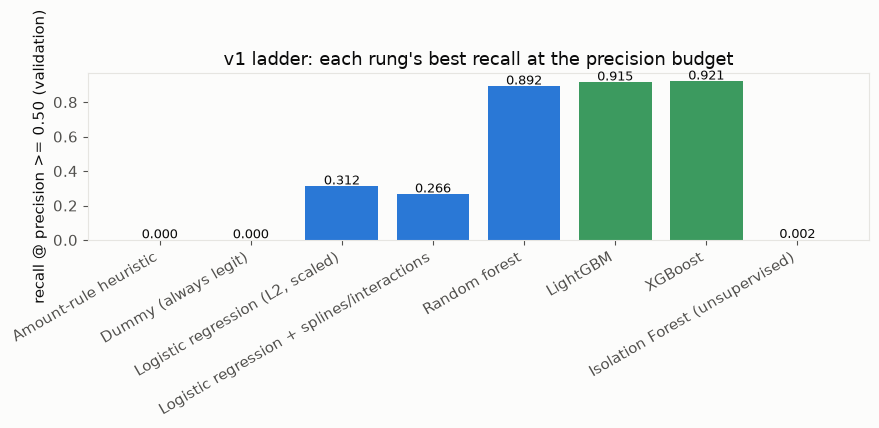

In [2]:
v1 = ladder[ladder["feature_set"] == "v1"].sort_values("step_id")
fig, ax = plt.subplots(figsize=(9, 4))
colors = [ACCENT if k in ("lightgbm", "xgboost") else LEGIT for k in v1["key"]]
ax.bar(v1["name"], v1["recall_at_precision"], color=colors)
ax.set_ylabel("recall @ precision >= 0.50 (validation)")
ax.set_title("v1 ladder: each rung's best recall at the precision budget")
plt.setp(ax.get_xticklabels(), rotation=30, ha="right")
for i, (_, row) in enumerate(v1.iterrows()):
    ax.text(
        i,
        row["recall_at_precision"] + 0.01,
        f"{row['recall_at_precision']:.3f}",
        ha="center",
        fontsize=9,
    )
plt.tight_layout()
plt.show()

XGBoost narrowly leads the v1 ladder (0.921) over LightGBM (0.915) and random forest (0.892).
Isolation Forest, trained without labels, is close to useless here (recall ~0.002) — with 0.5% fraud
spread across mostly one-hot categorical dimensions, "anomalous" is not the same thing as
"fraudulent" in this feature space; the labels are carrying almost all of the signal.

## 2. Protocol step 4: v1 vs v2 for the top two models

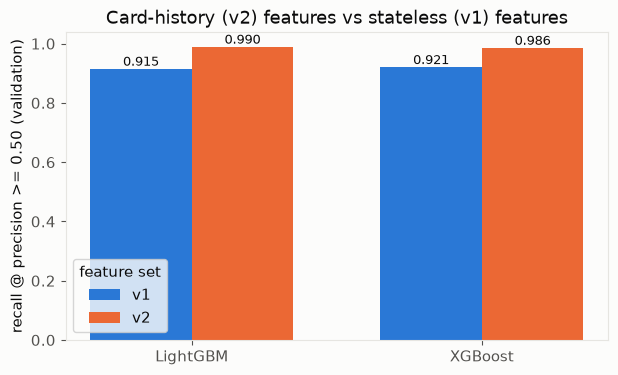

,key,feature_set,hyperparams,recall_at_precision,pr_auc
5,lightgbm,v1,"{'n_estimators': 250, 'num_leaves': 37, 'learn...",0.915428,0.874446
6,lightgbm,v2,"{'n_estimators': 450, 'num_leaves': 126, 'lear...",0.989777,0.977837
7,xgboost,v1,"{'n_estimators': 350, 'max_depth': 10, 'learni...",0.921004,0.888198
8,xgboost,v2,"{'n_estimators': 600, 'max_depth': 6, 'learnin...",0.986059,0.977679


In [3]:
top2 = ladder[ladder["key"].isin(["lightgbm", "xgboost"])].sort_values(["key", "feature_set"])
fig, ax = plt.subplots(figsize=(7, 4))
keys, sets = ["lightgbm", "xgboost"], ["v1", "v2"]
x = range(len(keys))
width = 0.35
for i, fs in enumerate(sets):
    vals = [
        top2[(top2["key"] == k) & (top2["feature_set"] == fs)]["recall_at_precision"].iloc[0]
        for k in keys
    ]
    bars = ax.bar(
        [xi + (i - 0.5) * width for xi in x], vals, width, label=fs, color=[LEGIT, FRAUD][i]
    )
    for xi, v in zip(x, vals, strict=True):
        ax.text(xi + (i - 0.5) * width, v + 0.01, f"{v:.3f}", ha="center", fontsize=9)
ax.set_xticks(list(x))
ax.set_xticklabels(["LightGBM", "XGBoost"])
ax.set_ylabel("recall @ precision >= 0.50 (validation)")
ax.set_title("Card-history (v2) features vs stateless (v1) features")
ax.legend(title="feature set")
plt.show()

top2[["key", "feature_set", "hyperparams", "recall_at_precision", "pr_auc"]]

## 3. Conclusions

**Every non-linear v1 model clears the linear ladder by a wide margin**: random forest (0.892),
LightGBM (0.915) and XGBoost (0.921) all sit 55-60 points of recall above logistic regression
(0.312). XGBoost is the v1 leader, narrowly ahead of LightGBM.

**Card-history features are worth far more than model choice.** Moving LightGBM and XGBoost from v1
to v2 features adds roughly 7-8 points of recall each — a bigger jump than the entire gap between
random forest and XGBoost on v1. This directly motivates the added complexity of ADR 0003's
stateful pipeline (online card-history store in Phase 5): the payoff is real and large, not marginal.

**LightGBM overtakes XGBoost once history features are added** (0.990 vs 0.986 recall on v2),
reversing the v1 ranking. The gap is narrow enough (0.6 points on v1, 0.4 on v2) that either would
be a defensible choice; LightGBM is picked as champion for the higher v2 number, with XGBoost v2
registered as `challenger` in the MLflow registry rather than discarded.

**Isolation Forest confirms this is a supervised problem.** Its recall (0.002) is barely above the
dummy floor (0.000) despite using the same v1 features as every other model — the fraud/legitimate
boundary here is not well captured by a general anomaly notion, and the labelled ladder rungs above
it do essentially all of the useful work.